# **Proyek Cek-Gula**

dataset: [Dataset Gambar Jajan](https://drive.google.com/drive/folders/1MsjZWiTL2-V22t-O_Mv80VX7JrlNP18l?usp=sharing)

## **Tugas:**

- Membangun model Deep Learning menggunakan TensorFlow Functional API atau Model Subclassing, yang disesuaikan dengan dataset dan permasalahan bisnis yang telah ditentukan oleh tim Data Science (jika ada).
- Mengimplementasikan setidaknya satu komponen kustom lanjutan dalam proses pengembangan model, seperti:
  - Custom Layer
  - Custom Loss Function
  - Custom Callback
- Menyimpan dan mengekspor model yang telah dilatih secara penuh dalam format TensorFlow siap produksi (.keras atau SavedModel).
- Membuat kode sederhana untuk proses inference model.

## **Tindakan yang Dilarang:**

- Menggunakan model yang sudah tersedia dari TensorFlow Hub atau sumber serupa.
- Menggunakan model langsung dari layanan API seperti ChatGPT API, Gemini API, dan sejenisnya.
- Menggunakan AutoML untuk membuat model Al diskriminatif (Vertex Al hanya diperbolehkan untuk use case Generative Al).

## **Side Quest:**

- Mengembangkan REST API mandiri menggunakan FastAPI atau Flask untuk melayani model machine learning.
- Mengimplementasikan training dan evaluation loop kustom secara penuh dari awal menggunakan tf.GradientTape.
- Menggunakan API Generative Al untuk fitur tambahan atau fitur sekunder pada aplikasi.
- Mengintegrasikan TensorBoard untuk memantau dan memvisualisasikan metrik pelatihan secara menyeluruh, serta menyertakan log yang dihasilkan dalam repository akhir.
- Memastikan model memiliki performa yang baik, dengan ketentuan minimum:
  - Akurasi minimal: 85%
  - MAE maksimal: 0,02


## **Import Library**


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import pandas as pd

## **Load & Preprocessing Data**


In [2]:
DATASET_PATH = 'dataset_gambar'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
CORRUPTED = []
AUTOTUNE = tf.data.AUTOTUNE

In [3]:
all_files = []
for root, dirs, files in os.walk(DATASET_PATH):
	for fname in files:
		if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
			all_files.append(os.path.join(root, fname))

print(f"Total file: {len(all_files)}")

Total file: 8835


In [4]:
for i, fpath in enumerate(all_files):
	try:
		raw = tf.io.read_file(fpath)
		tf.image.decode_image(raw, channels=3, expand_animations=False)
	except Exception as e:
		print(f"[KORUP] {fpath}\n		→ {e}")
		CORRUPTED.append(fpath)
	
	if (i+1) % 500 == 0:
		print(f"Progress: {i+1}/{len(all_files)}")

print(f"\nSelesai. Total bermasalah: {len(CORRUPTED)}")

Progress: 500/8835
Progress: 1000/8835
Progress: 1500/8835
Progress: 2000/8835
Progress: 2500/8835
Progress: 3000/8835
Progress: 3500/8835
Progress: 4000/8835
Progress: 4500/8835
Progress: 5000/8835
Progress: 5500/8835
Progress: 6000/8835
Progress: 6500/8835
Progress: 7000/8835
Progress: 7500/8835
Progress: 8000/8835
Progress: 8500/8835

Selesai. Total bermasalah: 0


In [5]:
for fpath in CORRUPTED:
  os.remove(fpath)
  print(f"Dihapus: {fpath}")

In [3]:
class_names = sorted(os.listdir(DATASET_PATH))
num_classes = len(class_names)
class_to_idx = {name: i for i, name in enumerate(class_names)}

In [4]:
all_paths, all_labels = [], []
for class_name in class_names:
  class_dir = os.path.join(DATASET_PATH, class_name)
  if not os.path.isdir(class_dir):
    continue
  for fname in os.listdir(class_dir):
    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
      all_paths.append(os.path.join(class_dir, fname))
      all_labels.append(class_to_idx[class_name])

In [5]:
def load_image(path, label):
  img = tf.io.read_file(path)
  img = tf.image.decode_image(img, channels=3, expand_animations=False)
  img = tf.image.resize(img, IMG_SIZE)
  img = tf.cast(img, tf.float32)
  label = tf.one_hot(label, num_classes)
  return img, label

In [6]:
full_ds = tf.data.Dataset.from_tensor_slices((all_paths, all_labels))
full_ds = full_ds.shuffle(len(all_paths), seed=123)

total = len(all_paths)
train_size = int(total * 0.8)

In [7]:
train_dataset = (
  full_ds.take(train_size)
	.map(load_image,num_parallel_calls=AUTOTUNE)
	.batch(BATCH_SIZE)
	.prefetch(AUTOTUNE)
)

In [8]:
val_dataset = (
	full_ds.skip(train_size)
	.map(load_image, num_parallel_calls=AUTOTUNE)
	.batch(BATCH_SIZE)
	.prefetch(AUTOTUNE)
)

In [9]:
print(f"Train: {train_size} | Val: {total - train_size} | Kelas: {num_classes}")
print("\nClass names:", class_names)

Train: 7068 | Val: 1767 | Kelas: 100

Class names: ['ampyang', 'arem-arem', 'arum manis', 'bakpao', 'bakwan', 'biji salak', 'bika ambon', 'bolen', 'bolu gulung', 'bolu karamel', 'bolu kukus', 'brem', 'bubur mutiara', 'bubur sumsum', 'cenil', 'cilok', 'cimol', 'cireng', 'combro', 'dadar gulung', 'dodol', 'donat', 'gathot', 'geplak', 'getas', 'gethuk pisang', 'getuk goreng', 'getuk lindri', 'kembang goyang', 'keripik pisang', 'keripik singkong', 'keripik tempe', 'keukarah', 'klepon', 'kroket', 'kue akar kelapa', 'kue ape', 'kue apem', 'kue balok', 'kue bangkit', 'kue bawang', 'kue bingka', 'kue carabikang', 'kue cubit', 'kue cucur', 'kue gemblong', 'kue jipang', 'kue kacang', 'kue kamir', 'kue klemben', 'kue lekker', 'kue lidah kucing', 'kue lumpang', 'kue lumpur', 'kue lupis', 'kue manco', 'kue mendut', 'kue mochi', 'kue padamaran', 'kue pancong', 'kue pastel', 'kue pasung', 'kue perut ayam', 'kue pudak', 'kue pukis', 'kue putri mandi', 'kue putu', 'kue putu ayu', 'kue rangi', 'kue sago

## **Custom Callback**


In [10]:
class TargetAccuracyCallback(tf.keras.callbacks.Callback):
  def __init__(self, target_accuracy=0.95):
    super(TargetAccuracyCallback, self).__init__()
    self.target_accuracy = target_accuracy
    
  def on_epoch_end(self, epoch, logs=None):
    val_acc = logs.get('val_accuracy')
    if val_acc is not None and val_acc >= self.target_accuracy:
      print(f"\n[INFO] Akurasi validasi mencapai {val_acc*100:.2f}% (Target: {self.target_accuracy*100:.2f}%).")
      print("[INFO] Menghentikan proses training agar tidak overfitting!")
      self.model.stop_training = True

## **Custom Layer**


In [11]:
class NormalisasiGambar(tf.keras.layers.Layer):
  def __init__(self, **kwargs):
    super(NormalisasiGambar, self).__init__(**kwargs)
    
  def call(self, inputs):
    inputs = tf.cast(inputs, tf.float32)
    return (inputs / 127.5) - 1.0
  
  def get_config(self):
    config = super(NormalisasiGambar, self).get_config()
    return config

## **Membangun Model dengan Functional API**


In [12]:
def build_functional_model(num_classes):
  inputs = tf.keras.Input(shape=(224, 224, 3), name="input_gambar")
  
  # Augmentasi
  x = layers.RandomFlip("horizontal")(inputs)
  x = layers.RandomRotation(0.15)(x)
  x = layers.RandomZoom(0.15)(x)
  x = layers.RandomContrast(0.1)(x)
  
  # Custom Layer 
  x = NormalisasiGambar(name="normalisasi_gambar")(x)
  
  # Base model pretrained
  base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
	)
  base_model.trainable = False
  
  x = base_model(x, training=False)
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dense(512, activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = layers.Dropout(0.5)(x)
  
  outputs = layers.Dense(num_classes, activation='softmax', name="prediksi_kelas")(x)
  model = tf.keras.Model(inputs=inputs, outputs=outputs, name="Model_Cek_Gula")
  return model

In [14]:
model = build_functional_model(num_classes=num_classes)

for layer in model.layers:
  if 'normalisasi' in layer.name:
    print(f"Custom Layer: {layer.name} - {layer.__class__.__name__}")

model.summary()

Custom Layer: normalisasi_gambar - NormalisasiGambar


Model: "Model_Cek_Gula"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_gambar (InputLayer)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalisasi_gambar              │ (None, 224, 224, 3)    │             0 │
│ (NormalisasiGambar)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediksi_kelas (Dense)          │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,967,204 (11.32 MB)

 Trainable params: 708,196 (2.70 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

## **Training Model**


In [16]:
model.compile(
	optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
	loss='categorical_crossentropy',
	metrics=['accuracy', 'mae']
)

In [17]:
custom_callback = TargetAccuracyCallback(target_accuracy=0.95)

In [18]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
	monitor='val_accuracy', factor=0.5,
	patience=3, min_lr=1e-6,
	verbose=1
)

In [19]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
	filepath='best_model.keras', monitor='val_accuracy',
	save_best_only=True, verbose=1
)

In [20]:
early_stop = tf.keras.callbacks.EarlyStopping(
	monitor='val_accuracy', patience=7,
	restore_best_weights=True, verbose=1
)

In [21]:
history = model.fit(
  train_dataset, 
  validation_data=val_dataset,
	epochs=50, 
	callbacks=[custom_callback, reduce_lr, checkpoint, early_stop]
)

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.1124 - loss: 4.5436 - mae: 0.0187
Epoch 1: val_accuracy improved from None to 0.53254, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 210s 914ms/step - accuracy: 0.1993 - loss: 3.7413 - mae: 0.0177 - val_accuracy: 0.5325 - val_loss: 1.9719 - val_mae: 0.0141 - learning_rate: 5.0000e-04
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4248 - loss: 2.3529 - mae: 0.0146
Epoch 2: val_accuracy improved from 0.53254 to 0.64346, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 445s 2s/step - accuracy: 0.4462 - loss: 2.2424 - mae: 0.0142 - val_accuracy: 0.6435 - val_loss: 1.4129 - val_mae: 0.0111 - learning_rate: 5.0000e-04
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5472 - loss: 1.7795 - mae: 0.0123
Epoch 3: val_accuracy improved from 0.64346 to 0.72213, saving

## **Visualisasi Hasil Training**


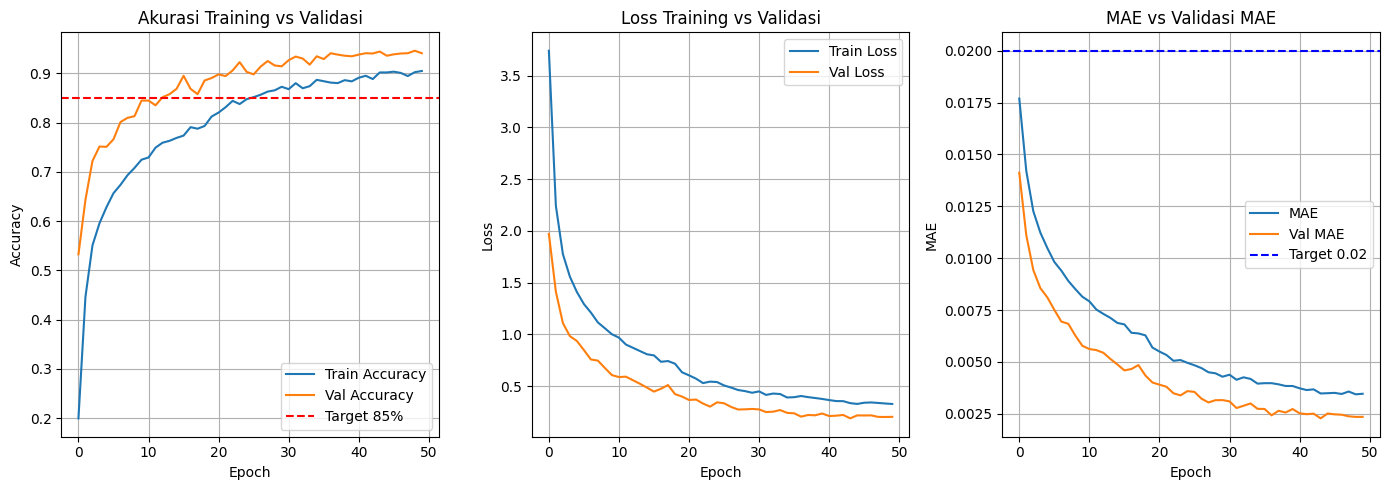

In [39]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

# Akurasi
ax1.plot(history.history['accuracy'], label="Train Accuracy")
ax1.plot(history.history['val_accuracy'], label="Val Accuracy")
ax1.axhline(y=0.85, color='r', linestyle='--', label='Target 85%')
ax1.set_title("Akurasi Training vs Validasi")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'], label="Train Loss")
ax2.plot(history.history['val_loss'], label="Val Loss")
ax2.set_title("Loss Training vs Validasi")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

# MAE
ax3.plot(history.history['mae'], label="MAE")
ax3.plot(history.history['val_mae'], label="Val MAE")
ax3.axhline(y=0.02, color='b', linestyle='--', label='Target 0.02')
ax3.set_title("MAE vs Validasi MAE")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("MAE")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.savefig('train_history.png', dpi=150)
plt.show()

In [29]:
best_val_acc = max(history.history['val_accuracy'])
print(f"\nPengecekkan Accuracy :")
print(f"Best Val Accuracy : {best_val_acc*100:.2f}%")
print(f"Target : 85.00%")
print(f"Status : {'✅ TERCAPAI' if best_val_acc >= 0.85 else '❌ Belum tercapai'}")


Pengecekkan Accuracy :
Best Val Accuracy : 94.62%
Target : 85.00%
Status : ✅ TERCAPAI


In [30]:
best_val_mae = min(history.history['val_mae'])
print(f"\nPengecekkan MAE :")
print(f"Best Val MAE : {best_val_mae:.4f}")
print(f"Target Maksimal : 0.02")
print(f"Status : {'✅ TERCAPAI' if best_val_mae <= 0.02 else '❌ Belum tercapai'}")


Pengecekkan MAE :
Best Val MAE : 0.0023
Target Maksimal : 0.02
Status : ✅ TERCAPAI


## **Save Model**


In [31]:
model.save('model_cek_gula.keras')

## **Dataset Nutrisi Jajan**


In [32]:
df_nutrisi = pd.read_csv('nutrisi_jajanan.csv', index_col='nama_jajanan')
NUTRISI = df_nutrisi.to_dict(orient='index')

print(f"Dataset nutrisi : {len(NUTRISI)} jenis jajanan")
df_nutrisi

Dataset nutrisi : 100 jenis jajanan


,kalori,karbohidrat,gula,protein,lemak,GI,GL
nama_jajanan,,,,,,,
ampyang,380,68.0,45.0,8.0,10.0,55,37.4
arem-arem,150,28.0,1.0,4.0,2.5,60,16.8
arum manis,390,75.0,60.0,2.0,8.0,70,52.5
bakpao,220,38.0,8.0,6.5,5.0,65,24.7
bakwan,175,20.0,1.5,5.0,8.0,55,11.0
...,...,...,...,...,...,...,...
tape ketan,165,38.0,20.0,2.0,0.5,65,24.7
tape singkong,145,34.0,18.0,1.5,0.5,60,20.4
tempe mendoan,200,16.0,1.0,12.0,10.0,45,7.2


## **Inference Model**


In [33]:
class NormalisasiGambar(tf.keras.layers.Layer):
	def __init__(self, **kwargs):
		super(NormalisasiGambar, self).__init__(**kwargs)

	def call(self, inputs):
		inputs = tf.cast(inputs, tf.float32)
		return (inputs / 127.5) - 1.0

	def get_config(self):
		config = super(NormalisasiGambar, self).get_config()
		return config

In [34]:
def kategori_resiko_gula(kadar_gula, gylcemic_load):
  if gylcemic_load < 10:
    return "🟢 RENDAH", "Aman dikonsumsi, risiko lonjakan gula minimal"
  elif gylcemic_load <20:
    return "🟡 SEDANG", "Konsumsi wajar, perhatikan porsi"
  else:
    return "🔴 TINGGI", "Batasi konsumsi, risiko sugar crash tinggi!"

In [37]:
def predict_gula(image_path, model, class_names, 
                 nutrisi_dict, porsi_gram=100):
  img = tf.io.read_file(image_path)
  img = tf.image.decode_image(img, channels=3, expand_animations=False)
  img = tf.image.resize(img, (224, 224))
  img_batch = tf.expand_dims(img, axis=0)
  
  predictions = model.predict(img_batch, verbose=0)
  predicted_idx = tf.argmax(predictions[0]).numpy()
  confidence = float(predictions[0][predicted_idx]) * 100
  
  top3_idx = tf.argsort(predictions[0], direction='DESCENDING')[:3]
  nama_jajanan = class_names[predicted_idx]
  
  print("=" * 50)
  print(f" 	HASIL ANALISIS CEK-GULA")
  print("=" * 50)
  print(f"  Jajanan    : {nama_jajanan.upper()}")
  print(f"  Keyakinan  : {confidence:.1f}%")
  print(f"  Porsi      : {porsi_gram}g")
  print("-" * 50)
  
  faktor_porsi = porsi_gram / 100.0
  if nama_jajanan in nutrisi_dict:
    n = nutrisi_dict[nama_jajanan]
    kalori    = n['kalori']    	 * faktor_porsi
    karbo     = n['karbohidrat'] * faktor_porsi
    gula      = n['gula']      	 * faktor_porsi
    protein   = n['protein']   	 * faktor_porsi
    lemak     = n['lemak']     	 * faktor_porsi
    gi        = n['GI']
    gl        = n['GL']        	 * faktor_porsi
    risiko, pesan = kategori_resiko_gula(gula, gl)
    
    print(f"	INFO NUTRISI (per {porsi_gram}g)")
    print(f"  Kalori     : {kalori:.0f} kkal")
    print(f"  Karbohidrat: {karbo:.1f} g")
    print(f"  Gula       : {gula:.1f} g kadar gula")
    print(f"  Protein    : {protein:.1f} g")
    print(f"  Lemak      : {lemak:.1f} g")
    print("-" * 50)
    print(f"  INDEKS GLIKEMIK (GI) : {gi}")
    print(f"  BEBAN GLIKEMIK  (GL) : {gl:.1f}")
    print(f"  Risiko     : {risiko}")
    print(f"  Info       : {pesan}")
    
  else:
    kalori = karbo = gula = protein = lemak = gi = gl = None
    resiko, pesan = "⚪ TIDAK DIKETAHUI", "Data nutrisi belum tersedia"

  print("-" * 50)
  print(f"  Top 3 Prediksi:")
  for i, idx in enumerate(top3_idx):
    print(f"     {i+1}. {class_names[idx]:<20} ({predictions[0][idx]*100:.1f}%)")
  print("=" * 50)
  
  return {
		'jajanan': nama_jajanan,
		'confidence': confidence,
		'gula_gram': gula,
		'kalori': kalori,
		'GI': gi,
		'GL': gl,
		'risiko': risiko
	}

In [38]:
model_path = 'best_model.keras'
model_gula = tf.keras.models.load_model(model_path, custom_objects={'NormalisasiGambar': NormalisasiGambar})

hasil = predict_gula(
	image_path='images.jpg',
	model=model_gula,
	class_names=class_names,
	nutrisi_dict=NUTRISI,
	porsi_gram=100
)

 	HASIL ANALISIS CEK-GULA
  Jajanan    : KROKET
  Keyakinan  : 88.6%
  Porsi      : 100g
--------------------------------------------------
	INFO NUTRISI (per 100g)
  Kalori     : 195 kkal
  Karbohidrat: 22.0 g
  Gula       : 2.0 g kadar gula
  Protein    : 6.5 g
  Lemak      : 9.0 g
--------------------------------------------------
  INDEKS GLIKEMIK (GI) : 55
  BEBAN GLIKEMIK  (GL) : 12.1
  Risiko     : 🟡 SEDANG
  Info       : Konsumsi wajar, perhatikan porsi
--------------------------------------------------
  Top 3 Prediksi:
     1. kroket               (88.6%)
     2. risol                (6.3%)
     3. kue bingka           (1.4%)
